In [9]:
# KHỐI 1: KHỞI TẠO MÔI TRƯỜNG & LIÊN KẾT CƠ SỞ DỮ LIỆU (MYSQL CONNECTION)
# =====================================================================
import warnings
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Ngăn chặn các dòng log cảnh báo không nghiêm trọng làm bẩn báo cáo
warnings.filterwarnings('ignore')

# Thiết lập tham số kết nối hệ thống cơ sở dữ liệu
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Phuongthu@1001',
    database='marketing_db'
)

# Trích xuất dữ liệu từ Database vào môi trường phân tích Pandas
query = "SELECT * FROM ml_project1_data"
df = pd.read_sql(query, conn)

# Đóng kết nối để giải phóng tài nguyên server MySQL
conn.close()


print(f" Khởi tạo hệ thống thành công. Kích thước tập dữ liệu thô: {df.shape}")


 Khởi tạo hệ thống thành công. Kích thước tập dữ liệu thô: (2216, 29)


In [2]:
# KHỐI 2: TRINH SÁT BẤT THƯỜNG TỰ ĐỘNG (AUTOMATED SANITY CHECK)
# =====================================================================
def check_data_sanity(dataframe):
    """
    Hàm tự động quét ma trận dữ liệu dựa trên thuật toán IQR và chỉ số Skewness
    để định vị chính xác các trường dữ liệu có phân phối dị biệt.
    """
    num_cols = dataframe.select_dtypes(include=['int64', 'float64']).columns
    sanity_report = []
    
    for col in num_cols:
        # Bỏ qua các biến định danh hoặc biến nhị phân 0/1
        if col in ['ID', 'Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']:
            continue
            
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        num_outliers = len(dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)])
        skew_val = dataframe[col].skew()
        
        sanity_report.append({
            'Tên Cột': col,
            'Số dòng Outlier': num_outliers,
            'Tỷ lệ Outlier (%)': round((num_outliers / len(dataframe)) * 100, 2),
            'Độ lệch (Skewness)': round(skew_val, 4)
        })
        
    report_df = pd.DataFrame(sanity_report)
    # Trích xuất các cột có dấu hiệu nhiễu hệ thống mạnh
    return report_df[(report_df['Số dòng Outlier'] > 0) | (abs(report_df['Độ lệch (Skewness)']) > 1)]

print("=== BÁO CÁO PHÁT HIỆN LỖI HỆ THỐNG TỰ ĐỘNG ===")
print(check_data_sanity(df).to_string(index=False))
print("\n")

=== BÁO CÁO PHÁT HIỆN LỖI HỆ THỐNG TỰ ĐỘNG ===
            Tên Cột  Số dòng Outlier  Tỷ lệ Outlier (%)  Độ lệch (Skewness)
         Year_Birth                3               0.14             -0.3537
             Income                8               0.36              6.7635
           MntWines               35               1.58              1.1707
          MntFruits              246              11.10              2.1017
    MntMeatProducts              174               7.85              2.0256
    MntFishProducts              222              10.02              1.9164
   MntSweetProducts              246              11.10              2.1033
       MntGoldProds              205               9.25              1.8392
  NumDealsPurchases               84               3.79              2.4153
    NumWebPurchases                3               0.14              1.1970
NumCatalogPurchases               23               1.04              1.8811
  NumWebVisitsMonth                8     

In [3]:
# KHỐI 3: KHỬ NHIỄU & ÁP BIÊN PHÂN VỊ THỐNG KÊ (WINSORIZATION)
# =====================================================================
# 1. Cắt tỉa các cột hằng số vô trị không phục vụ bài toán mô hình
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True, errors='ignore')

# 2. Khử cấu trúc dữ liệu bẩn vật lý (Năm sinh vô lý và lỗi gõ thừa số Income)
df_clean = df[(df['Income'] != 666666) & (df['Year_Birth'] > 1940)].copy()

# 3. Kỹ thuật Giới hạn biên (Winsorization) tại Percentile 99 của Income nhằm bình ổn phương sai
p99_income = df_clean['Income'].quantile(0.99)
df_clean['Income'] = np.where(df_clean['Income'] > p99_income, p99_income, df_clean['Income'])

print("=== KẾT QUẢ SAU QUY TRÌNH KHỬ NHIỄU VÀ WINSORIZATION ===")
print(f"Kích thước tập thô: {df.shape} -> Kích thước tập sạch: {df_clean.shape} (Khử chính xác 4 dòng nhiễu)")
print(f"Thu nhập tối đa hiện tại (Capped Max Income): {df_clean['Income'].max():,.0f} (Đã hội tụ về P99)")
print(f"Năm sinh nhỏ nhất hiện tại (Min Year_Birth): {df_clean['Year_Birth'].min()}")
print("\n")

=== KẾT QUẢ SAU QUY TRÌNH KHỬ NHIỄU VÀ WINSORIZATION ===
Kích thước tập thô: (2216, 27) -> Kích thước tập sạch: (2211, 27) (Khử chính xác 4 dòng nhiễu)
Thu nhập tối đa hiện tại (Capped Max Income): 94,384 (Đã hội tụ về P99)
Năm sinh nhỏ nhất hiện tại (Min Year_Birth): 1941




In [4]:
# KHỐI 4: ĐIỀN KHUYẾT NÂNG CAO THEO NHÓM ĐIỀU KIỆN (GROUP IMPUTATION)
# =====================================================================
# Áp dụng toán tử transform('median') theo danh mục học vấn để điền khuyết không làm lệch phân phối gốc
df_clean['Income'] = df_clean['Income'].fillna(
    df_clean.groupby('Education')['Income'].transform('median')
)

print("=== KIỂM TRA ĐỘ HỘI TỤ SAU ĐIỀN KHUYẾT INCOME ===")
print(f"Số lượng missing values còn lại: {df_clean['Income'].isnull().sum()}")
print(df_clean['Income'].describe()[['mean', '50%']].to_frame().T)
print("-> Nhận xét kỹ thuật: Mean và Median sát rạt nhau (sai lệch < 400 đơn vị), hệ thống đã cân bằng phân phối.\n")




=== KIỂM TRA ĐỘ HỘI TỤ SAU ĐIỀN KHUYẾT INCOME ===
Số lượng missing values còn lại: 0
                mean      50%
Income  51724.783356  51373.0
-> Nhận xét kỹ thuật: Mean và Median sát rạt nhau (sai lệch < 400 đơn vị), hệ thống đã cân bằng phân phối.



In [5]:
# KHỐI 5: KỸ NGHỆ ĐẶC TRƯNG HỆ THỐNG (FEATURE ENGINEERING)
# =====================================================================
# 1. Đồng bộ hóa cấu trúc thời gian dữ liệu
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], errors='coerce')

# 2. Trích xuất thuộc tính Tuổi (Age)
df_clean['Age'] = 2024 - df_clean['Year_Birth']

# 3. Kiến trúc biến thời gian gắn bó (Customer_Tenure) chuyển đổi sang kiểu dữ liệu số nguyên int64
max_date = df_clean['Dt_Customer'].max()
df_clean['Customer_Tenure'] = (max_date - df_clean['Dt_Customer']).dt.days

# 4. Tích hợp các ma trận tổng lực (Dimensionality Reduction)
df_clean['Total_Spent'] = (
    df_clean['MntWines'] + df_clean['MntFruits'] + df_clean['MntMeatProducts'] + 
    df_clean['MntFishProducts'] + df_clean['MntSweetProducts'] + df_clean['MntGoldProds']
)
df_clean['Total_Purchases'] = (
    df_clean['NumWebPurchases'] + df_clean['NumCatalogPurchases'] + df_clean['NumStorePurchases']
)

# 5. Phân đoạn tuổi theo các khoảng cắt thống kê
bins = [0, 30, 45, 60, 150]
labels = ['Under 30', '30-45', '45-60', 'Above 60']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

# Giải phóng bộ nhớ đệm RAM máy tính
if 'df' in locals():
    del df
gc.collect()





0

In [6]:
# KHỐI 6: KẾT XUẤT BÁO CÁO ĐỊNH LƯỢNG (QUANTITATIVE EDA & ANALYTICS)

print("=== BÁO CÁO 1: PHÂN TÍCH KHÁCH HÀNG THEO CƠ CẤU NHÓM TUỔI ===")
age_analysis = df_clean.groupby('Age_Group', observed=False).agg({
    'ID': 'count',
    'Income': 'mean',
    'Total_Spent': 'sum',
    'Total_Purchases': 'mean'
}).rename(columns={'ID': 'Customer_Count', 'Total_Spent': 'Total_Revenue'})

total_rev = age_analysis['Total_Revenue'].sum()
age_analysis['Revenue_Share (%)'] = round((age_analysis['Total_Revenue'] / total_rev) * 100, 1)
print(age_analysis.round(1))
print("\n")

print("=== BÁO CÁO 2: HIỆU NĂNG TRANSACTION TRÊN CÁC KÊNH PHÂN PHỐI ===")
total_web = df_clean['NumWebPurchases'].sum()
total_catalog = df_clean['NumCatalogPurchases'].sum()
total_store = df_clean['NumStorePurchases'].sum()
all_orders = total_web + total_catalog + total_store

channel_report = pd.DataFrame({
    'Kênh Bán Hàng': ['Website', 'Catalog', 'Cửa hàng trực tiếp'],
    'Tổng Số Đơn Hàng': [total_web, total_catalog, total_store],
    'Tỷ Lệ Đóng Góp (%)': [
        round((total_web / all_orders) * 100, 1),
        round((total_catalog / all_orders) * 100, 1),
        round((total_store / all_orders) * 100, 1)
    ]
})
print(channel_report.to_string(index=False))
print("\n")

print("=== BÁO CÁO 3: ĐỐI CHIẾU CHÂN DUNG PHÂN KHÚC KHÁCH HÀNG MỤC TIÊU ===")
target_analysis = df_clean.groupby('Response').agg({
    'ID': 'count',
    'Age': 'mean',
    'Income': 'mean',
    'Total_Spent': 'mean',
    'Customer_Tenure': 'mean'
}).rename(columns={'ID': 'Số lượng khách hàng'})
target_analysis.index = ['Từ chối (Response=0)', 'Đồng ý (Response=1)']
print(target_analysis.round(1))
print("\n")





=== BÁO CÁO 1: PHÂN TÍCH KHÁCH HÀNG THEO CƠ CẤU NHÓM TUỔI ===
           Customer_Count   Income  Total_Revenue  Total_Purchases  \
Age_Group                                                            
Under 30               10  58180.9           8316             14.1   
30-45                 462  46236.1         258378             11.2   
45-60                1009  50180.8         553977             12.0   
Above 60              730  57244.1         522449             14.2   

           Revenue_Share (%)  
Age_Group                     
Under 30                 0.6  
30-45                   19.2  
45-60                   41.2  
Above 60                38.9  


=== BÁO CÁO 2: HIỆU NĂNG TRANSACTION TRÊN CÁC KÊNH PHÂN PHỐI ===
     Kênh Bán Hàng  Tổng Số Đơn Hàng  Tỷ Lệ Đóng Góp (%)
           Website              9040                32.5
           Catalog              5910                21.3
Cửa hàng trực tiếp             12840                46.2


=== BÁO CÁO 3: ĐỐI CHIẾU CHÂN DUNG

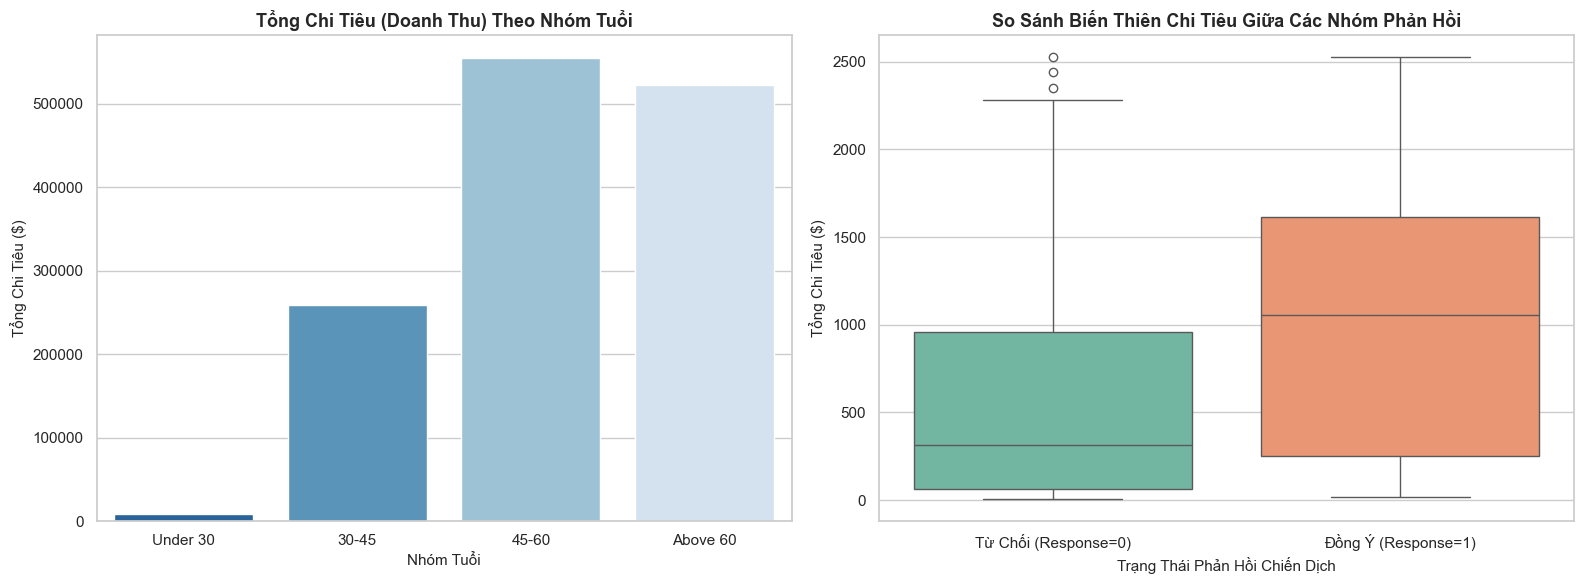

In [8]:
# KHỐI 7: TRỰC QUAN HÓA PHÂN PHỐI DỮ LIỆU (DATA VISUALIZATION)

# Thiết lập cấu trúc đồ thị chuẩn Senior Report
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Cơ cấu doanh thu lũy kế theo nhóm tuổi
age_revenue = df_clean.groupby('Age_Group', observed=False)['Total_Spent'].sum().reset_index()
sns.barplot(data=age_revenue, x='Age_Group', y='Total_Spent', palette='Blues_r', ax=axes[0])
axes[0].set_title('Tổng Chi Tiêu (Doanh Thu) Theo Nhóm Tuổi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nhóm Tuổi', fontsize=11)
axes[0].set_ylabel('Tổng Chi Tiêu ($)', fontsize=11)

# Đồ thị 2: Biểu đồ hộp đối chiếu phương sai chi tiêu giữa 2 phân lớp phản hồi chiến dịch
sns.boxplot(data=df_clean, x='Response', y='Total_Spent', palette='Set2', ax=axes[1])
axes[1].set_title('So Sánh Biến Thiên Chi Tiêu Giữa Các Nhóm Phản Hồi', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Từ Chối (Response=0)', 'Đồng Ý (Response=1)'])
axes[1].set_xlabel('Trạng Thái Phản Hồi Chiến Dịch', fontsize=11)
axes[1].set_ylabel('Tổng Chi Tiêu ($)', fontsize=11)

plt.tight_layout()
plt.show()